In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sys.path.append("../utility")
from model_performance_regression import regression_model_performance

warnings.filterwarnings("ignore")


In [2]:
data_path = os.path.join("..", "data", "clean_data", "encoded_tree_dataset_final.csv")
df = pd.read_csv(data_path)
df.head()

,State_Province,City,Latitude,Longitude,Elevation,Tree_Name,Tree_Age,Height_Meter,Trunk_Diameter_cm,Canopy_Width_m,...,Inspection_Frequency,Tree_Health_Status,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability,Soil_Type_Clayey,Soil_Type_Loamy,Soil_Type_Saline,Soil_Type_Sandy
0,0.03210,0.03210,23.017811,72.567292,53,0.02000,78,20.71,51.77,14.34,...,2,0,0.306,95,79.97,0.96,1,0,0,0
1,0.03250,0.03250,30.902437,75.867032,247,0.01945,70,17.82,44.54,12.34,...,2,0,0.581,95,68.83,1.00,1,0,0,0
2,0.03380,0.03380,28.621786,77.199431,217,0.02105,94,19.49,48.72,13.49,...,2,0,0.405,95,74.39,0.99,0,0,0,0
3,0.03470,0.03470,24.816504,93.940258,783,0.02070,19,13.63,34.07,9.44,...,2,0,0.570,95,54.78,0.99,0,0,1,0
4,0.03045,0.03045,12.980502,77.596770,920,0.01930,50,19.69,49.22,13.63,...,2,0,0.650,95,75.96,1.00,1,0,0,0


In [3]:
# feature and target separation
features = [
    'Tree_Name',
    'Tree_Age',
    'Height_Meter',
    'Trunk_Diameter_cm',
    'Canopy_Width_m',
    'Root_Depth_m',
    'Growth_Stage',
    'Temperature_C',
    'Rainfall_mm',
    'Humidity_Pct',
    'Wind_Speed_kmh',
    'Solar_Radiation_W_m2',
    'Drought_Index',
    'Soil_pH',
    'Nitrogen',
    'Phosphorus',
    'Potassium',
    'Organic_Carbon',
    'Water_Stress_Index',
    'Watering_Frequency',
    'Fertilizer_Usage',
    'Pruning_Count'
]

X = df[features]
y = df["Carbon_Absorption_kg"]

In [4]:
# train test split data

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## RandomForest Regressor

In [5]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [7]:
print(f"Traing Score : {rfr.score(X_train,y_train)}")
print(f"Testing Score : {rfr.score(X_test,y_test)}")

Traing Score : 0.9990777687072151
Testing Score : 0.9964920585227138


In [8]:
y_pred_rfr = rfr.predict(X_test)

In [9]:
# model performance

rfr_model_performance = regression_model_performance(y_test,y_pred_rfr)

Model Performance
------------------------------
MSE  : 0.7525462837799434
MAE  : 0.6822622510069094
RMSE : 0.8674942557619292
R² Score : 0.9964920585227138


In [10]:
# feature importance 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rfr.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
3,Trunk_Diameter_cm,0.226935
2,Height_Meter,0.209451
4,Canopy_Width_m,0.196523
5,Root_Depth_m,0.173469
1,Tree_Age,0.121571
6,Growth_Stage,0.063121
18,Water_Stress_Index,0.002003
19,Watering_Frequency,0.001161
12,Drought_Index,0.001025
20,Fertilizer_Usage,0.000984


In [11]:
# Cross Validation
from sklearn.model_selection import cross_val_score
import numpy as np

rfr_cv_scores = cross_val_score(
    rfr,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rfr_cv_mean = np.mean(rfr_cv_scores)
rfr_cv_std = np.std(rfr_cv_scores)

print("CV Scores:", rfr_cv_scores)
print("Mean CV Score:", np.mean(rfr_cv_mean))

CV Scores: [0.9965574  0.99667875 0.99653561 0.9966192  0.99641319]
Mean CV Score: 0.9965608303025233


In [13]:

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rfr
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])


print(df_results.head())


       Actual  Predicted     Error  Abs_Error
10650   76.07  76.475709 -0.405709   0.405709
2041    73.54  72.916911  0.623089   0.623089
8668    75.73  76.908570 -1.178570   1.178570
1114    78.50  78.755952 -0.255952   0.255952
13902   87.96  87.659457  0.300543   0.300543


In [13]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfr_random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=10,      
    cv=3,           
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rfr_random_search.fit(X_train, y_train)

print(f"Best Parameters: {rfr_random_search.best_params_}")
print(f"Best CV Score : {rfr_random_search.best_score_}")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score : 0.9203584565195548


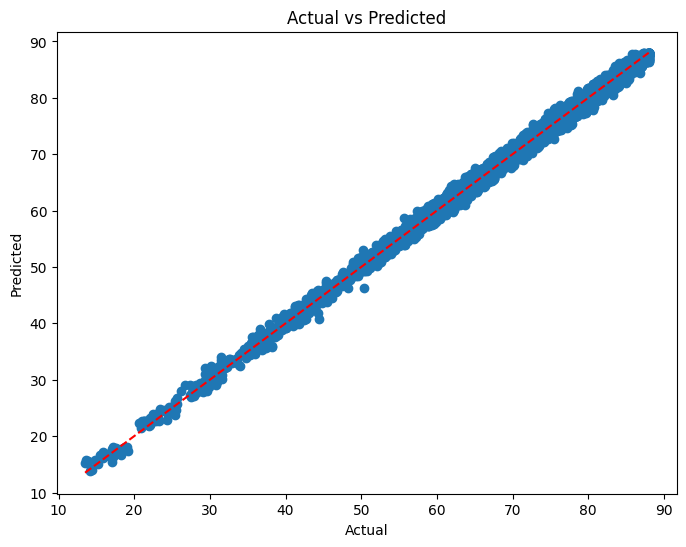

In [14]:
# Actual Value v/s Predicted Value
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            y_pred_rfr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## XGBoost Regressor

In [15]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
print(f"Traing Score : {xgb.score(X_train,y_train)}")
print(f"Testing Score : {xgb.score(X_test,y_test)}")

Traing Score : 0.9971589466570913
Testing Score : 0.9966454140524331


In [17]:
y_pred_xgb = xgb.predict(X_test)

In [18]:
# XGBoostRegressor Model Performance

xgb_model_performance = regression_model_performance(y_test,y_pred_xgb)

Model Performance
------------------------------
MSE  : 0.7196474641346808
MAE  : 0.6737047385883331
RMSE : 0.8483203782384818
R² Score : 0.9966454140524331


In [19]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
3,Trunk_Diameter_cm,0.335960
4,Canopy_Width_m,0.277158
2,Height_Meter,0.214364
5,Root_Depth_m,0.162456
19,Watering_Frequency,0.003328
1,Tree_Age,0.002142
20,Fertilizer_Usage,0.002030
18,Water_Stress_Index,0.001882
17,Organic_Carbon,0.000103
6,Growth_Stage,0.000076


In [20]:
# cross validation
from sklearn.model_selection import cross_val_score
import numpy as np
xgb_cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
xgb_cv_mean = np.mean(xgb_cv_scores)

print("CV Scores:", xgb_cv_scores)
print("Mean CV Score:", xgb_cv_mean)

CV Scores: [0.99666899 0.99677008 0.99659022 0.99672644 0.99651593]
Mean CV Score: 0.9966543305061739


In [21]:

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rfr
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])


print(df_results.head())


       Actual  Predicted     Error  Abs_Error
10650   76.07  76.475709 -0.405709   0.405709
2041    73.54  72.916911  0.623089   0.623089
8668    75.73  76.908570 -1.178570   1.178570
1114    78.50  78.755952 -0.255952   0.255952
13902   87.96  87.659457  0.300543   0.300543


In [32]:
# Hyperparameter Tuning

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator= xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42

)

xgb_random_search.fit(X_train,y_train)

print(f"Best CV Score : {xgb_random_search.best_score_}")
print(f"Best hyperparameters : {xgb_random_search.best_params_}")

Best CV Score : 0.9739814248285115
Best hyperparameters : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


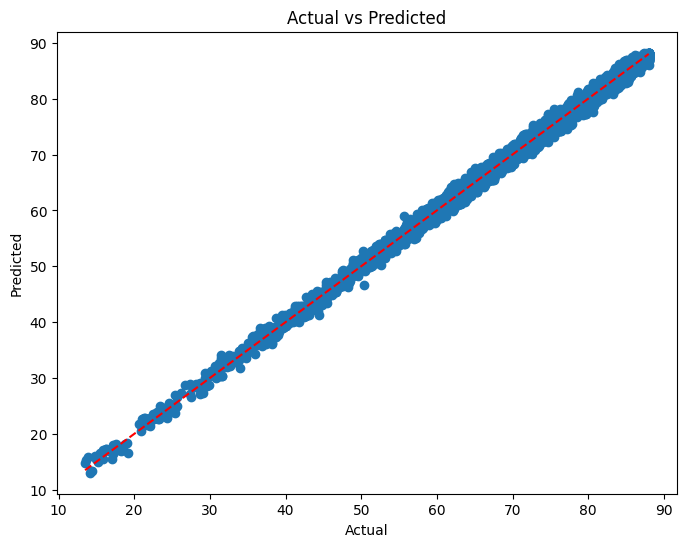

In [22]:
# Actual Value v/s Predicted Value
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            y_pred_xgb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## CatBoost Regreesor

In [23]:
from catboost import CatBoostRegressor

In [24]:
cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    l2_leaf_reg=5,
    subsample=0.8,
    verbose=0
)
cat.fit(X_train,y_train)

CatBoostRegressor(depth=6, eval_metric='R2', iterations=1000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, subsample=0.8, verbose=0)

In [25]:
print(f"Training Score : {cat.score(X_train,y_train)}")
print(f"Testing Score : {cat.score(X_test,y_test)}")

Training Score : 0.9972102145154524
Testing Score : 0.9966103492987543


In [28]:
cat_pred = cat.predict(X_test)

In [29]:
cat_model_performance = regression_model_performance(y_test,cat_pred)

Model Performance
------------------------------
MSE  : 0.7271697817798228
MAE  : 0.6761975305125247
RMSE : 0.852742506141111
R² Score : 0.9966103492987543


In [27]:
cross_val_scores = cross_val_score(
    cat,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print(f"Cross-Validation Scores: {cross_val_scores}")
print(f"Mean Cross-Validation Score: {cross_val_scores.mean()}")
print(f"Standard Deviation: {cross_val_scores.std()}")

Cross-Validation Scores: [0.99667778 0.99671552 0.99655017 0.99667015 0.9964545 ]
Mean Cross-Validation Score: 0.9966136248475401
Standard Deviation: 9.699729986400202e-05


In [31]:
# feature imprtance
cat_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat.get_feature_importance()
})
cat_feature_importance = cat_feature_importance.sort_values("Importance", ascending=False)
cat_feature_importance

,Feature,Importance
2,Height_Meter,28.253042
4,Canopy_Width_m,24.275587
3,Trunk_Diameter_cm,19.518805
5,Root_Depth_m,14.073451
1,Tree_Age,6.161146
6,Growth_Stage,4.924787
19,Watering_Frequency,0.669560
18,Water_Stress_Index,0.633657
20,Fertilizer_Usage,0.569502
12,Drought_Index,0.347204


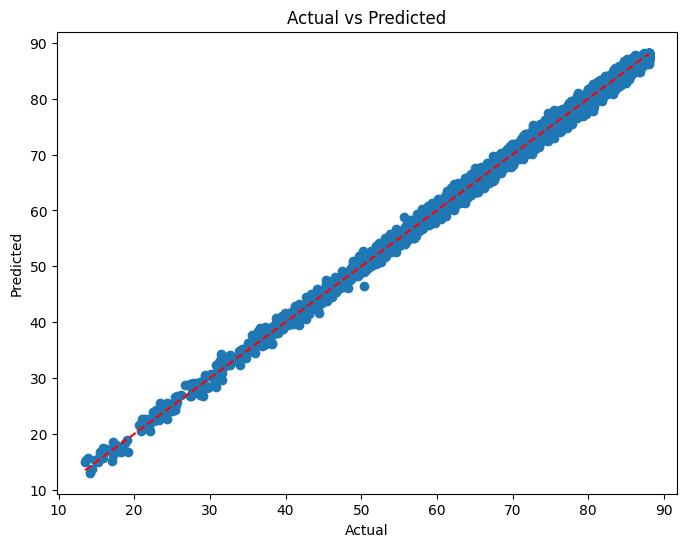

In [40]:
# Actual Value v/s Predicated Value
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            cat_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Model Performance Comparison

In [33]:
results = []


results.append([
    "Random Forest",
    rfr.score(X_train,y_train),
    rfr.score(X_test,y_test),
    rfr_model_performance["R2 Score"],
    rfr_model_performance["MAE"],
    rfr_model_performance["RMSE"]
])

results.append([
    "XGBoost",
    xgb.score(X_train,y_train),
    xgb.score(X_test,y_test),
    xgb_model_performance["R2 Score"],
    xgb_model_performance["MAE"],
    xgb_model_performance["RMSE"]
])

results.append([
    "CatBoost",
    cat.score(X_train,y_train),
    cat.score(X_test,y_test),
    cat_model_performance["R2 Score"],
    cat_model_performance["MAE"],
    cat_model_performance["RMSE"]
])


comparison = pd.DataFrame(
    results,
    columns=["Model","Training Score","Testing Score" ,"R2 Score", "MAE", "RMSE"]
)



## Cross Validation Mean Comparison

In [37]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "CV Mean R2": [
        np.mean(rfr_cv_scores),
        np.mean(xgb_cv_scores),
        np.mean(cross_val_scores)
    ],
    "CV Std": [
        np.std(rfr_cv_scores),
        np.std(xgb_cv_scores),
        np.std(cross_val_scores)
    ]
})

cv_comparison.sort_values(
    by="CV Mean R2",
    ascending=False,
    inplace=True
)
cv_comparison.reset_index(drop=True, inplace=True)


## Final Model Comparison Table

In [38]:
final_comparison = comparison.merge(
    cv_comparison,
    on="Model"
)

final_comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE,CV Mean R2,CV Std
1,XGBoost,0.997159,0.996645,0.996645,0.673705,0.848320,0.996654,0.000092
2,CatBoost,0.997210,0.996610,0.996610,0.676198,0.852743,0.996614,0.000097
0,Random Forest,0.999078,0.996492,0.996492,0.682262,0.867494,0.996561,0.000089


## Best Model Selection

In [39]:
best_model = comparison.sort_values(
    by="Testing Score",
    ascending=False
)

best_model.head(1)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE
1,XGBoost,0.997159,0.996645,0.996645,0.673705,0.84832


## Save Model

In [ ]:
import joblib

joblib.dump(
    xgb,
    "../models/Carbon_Prediction_Model.pkl"
)

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/Carbon_Prediction_Feature_Columns.pkl"
)


['../models/Carbon_Prediction_Feature_Columns_2.pkl']